In [1]:
# %load_ext autotime

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from ema_workbench import ema_logging
ema_logging.log_to_stderr(ema_logging.INFO)

<Logger EMA (DEBUG)>

In [6]:
from ema_workbench import save_results
from ema_workbench import load_results

#save_results(results, 'archexploration_500scenarios_340policies.tar.gz')
results = load_results('./data/archexploration_500scenarios_400policies_ff.tar.gz')
#results = load_results('archexploration_500scenarios_1policies.tar.gz')
#results = load_results('archexploration_500scenarios_1policies_sobol.tar.gz')
#results = load_results('archexploration_500scenarios_1policies_prim.tar.gz')
#results = load_results('archexploration_500scenarios_27policies.tar.gz')
#results = load_results('archexploration_1scenarios_500policies.tar.gz')

[MainProcess/INFO] results loaded successfully from /Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/data/archexploration_500scenarios_400policies_ff.tar.gz


In [7]:
experiments_df, outcomes = results
policies = experiments_df['policy']
print(experiments_df.shape)
print(list(outcomes.keys()))

(171500, 12)
['cost', 'executionTime', 'probSuccessfulExecution']


In [11]:
outcomes_df = pd.DataFrame(outcomes)
outcomes_df

,cost,executionTime,probSuccessfulExecution
0,0,94,0
1,0,81,0
2,0,72,0
3,0,46,0
4,0,65,0
...,...,...,...
171495,93,38,84
171496,162,31,86
171497,141,37,74
171498,132,24,71


In [12]:
experiments_df

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,109,23,49,27,5,18,0,0,0,343,0,archexploration
1,138,15,18,22,4,10,0,0,0,344,0,archexploration
2,104,21,44,30,3,48,0,0,0,345,0,archexploration
3,109,12,11,15,3,36,0,0,0,346,0,archexploration
4,147,13,11,18,1,27,0,0,0,347,0,archexploration
...,...,...,...,...,...,...,...,...,...,...,...,...
171495,105,1,22,16,5,11,6,6,6,838,342,archexploration
171496,125,36,13,14,3,17,6,6,6,839,342,archexploration
171497,114,17,27,17,5,49,6,6,6,840,342,archexploration
171498,107,14,11,28,5,30,6,6,6,841,342,archexploration


In [9]:
policies.unique()

[0, 1, 2, 3, 4, ..., 338, 339, 340, 341, 342]
Length: 343
Categories (343, int64): [0, 1, 2, 3, ..., 339, 340, 341, 342]

In [11]:
config_0_0_0_to_remove = experiments_df[(experiments_df.d1Services==0)&(experiments_df.d2Services==0)&(experiments_df.d3Services==0)].index
if len(config_0_0_0_to_remove) > 0:
    experiments_df.drop(experiments_df.index[config_0_0_0_to_remove], inplace=True)
    experiments_df.reset_index(drop=True, inplace=True)
experiments_df

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,111,33,43,19,3,29,0,0,1,2993,2651,archexploration
1,128,25,11,21,3,33,0,0,1,2994,2651,archexploration
2,118,20,32,19,4,43,0,0,1,2995,2651,archexploration
3,124,14,40,45,5,50,0,0,1,2996,2651,archexploration
4,136,29,36,45,3,31,0,0,1,2997,2651,archexploration
...,...,...,...,...,...,...,...,...,...,...,...,...
170995,145,32,29,47,2,32,6,6,6,3488,2992,archexploration
170996,127,15,19,27,1,22,6,6,6,3489,2992,archexploration
170997,137,39,27,24,4,47,6,6,6,3490,2992,archexploration
170998,130,19,14,16,4,17,6,6,6,3491,2992,archexploration


time: 88.2 ms (started: 2023-11-27 22:58:29 -03:00)


In [12]:
pd.DataFrame(outcomes).describe()

,cost,executionTime,probSuccessfulExecution
count,171500.000000,171500.000000,171500.000000
mean,78.413143,49.012595,65.130822
std,39.749254,14.457680,12.951221
min,0.000000,20.000000,0.000000
25%,47.000000,38.000000,55.000000
50%,76.000000,49.000000,65.000000
75%,107.000000,59.000000,75.000000
max,210.000000,111.000000,90.000000


time: 58.7 ms (started: 2023-11-27 22:58:34 -03:00)


In [13]:
# Split the values of the column into n buckets, according to the distribution of values
def get_distribution_bins(col, n, min_max=(None,None)): 
    unique_values = set(col.values)
    if min_max == (None,None):
        min_x = np.min(list(unique_values))
        max_x = np.max(list(unique_values))
    else:
        print("Using predefined limits",min_max)
        min_x = min_max[0]
        max_x = min_max[1]
    #print(min_x, max_x)
    unique_values.update([min_x, max_x])
    unique_values = sorted(unique_values)
    
    return sorted(set(pd.qcut(unique_values, n).map(lambda x: x.left, na_action="ignore"))) + [max(unique_values)]

def get_bins(col, n, min_max=(None,None)):
    unique_values = sorted((set(col.values)))
    if min_max == (None,None):
        min_x = np.min(unique_values)
        max_x = np.max(unique_values)
    else:
        #print("Using predefined limits",min_max)
        min_x = min_max[0]
        max_x = min_max[1]
    min_x = min_x - 0.1
    max_x = max_x + 0.1
    delta = (max_x - min_x)/n
    #print(min_x, max_x, delta)
    return ([min_x+i*delta for i in range(0,n)] + [max_x])

time: 1.98 ms (started: 2023-11-27 22:58:39 -03:00)


In [14]:
def plot_outcome_distribution(df_outcomes, n_bins=100, labels=5, filename=None, mins_maxs=(None,None)):
    #df_outcomes = pd.DataFrame(outcomes)
    qas = list(df_outcomes.columns)
    
    fig, axs = plt.subplots(len(qas), 1, sharey=True, tight_layout=True, figsize=(8,8))
    colors = ['b', 'r', 'g']
    for idx, qa in enumerate(qas):
        col = df_outcomes[qa]
        min_max = (None,None)
        if mins_maxs != (None,None):
            min_max = mins_maxs[idx]
            #print(min_max)
        #col_range = get_distribution_bins(col, labels, min_max)
        col_range = get_bins(col, labels, min_max)
        print(qa, col_range)
        if min_max != (None,None):
            col = col.tolist()
            col.append(min_max[0])
            col.append(min_max[1])
        axs[idx].hist(col, bins=n_bins, color=colors[idx])
        axs[idx].set_title(qa)
        for xc in col_range:
            axs[idx].axvline(x=xc, color='gray', linestyle='dashed')

    if filename is not None:
        plt.savefig(filename)
    plt.show()

time: 2.68 ms (started: 2023-11-27 22:58:41 -03:00)


In [15]:
outcomes_df = pd.DataFrame(outcomes)
if len(config_0_0_0_to_remove) > 0:
    outcomes_df.drop(outcomes_df.index[config_0_0_0_to_remove], inplace=True)
    outcomes_df.reset_index(drop=True, inplace=True)
outcomes_df

,cost,executionTime,probSuccessfulExecution
0,36,83,58
1,28,54,53
2,24,66,47
3,19,71,28
4,32,83,38
...,...,...,...
170995,132,46,52
170996,63,36,73
170997,189,40,69
170998,129,32,84


time: 16.6 ms (started: 2023-11-27 22:58:50 -03:00)


In [16]:
BINS = 3

#df_outcomes = pd.DataFrame(outcomes)
cost_min_max = get_distribution_bins(outcomes_df['cost'], BINS)
cost_min_max = (cost_min_max[0], cost_min_max[-1])
print(cost_min_max)
executiontime_min_max = get_distribution_bins(outcomes_df['executionTime'], BINS)
executiontime_min_max = (executiontime_min_max[0], executiontime_min_max[-1])
print(executiontime_min_max)
probsuccessfulexecution_min_max = get_distribution_bins(outcomes_df['probSuccessfulExecution'], BINS)
probsuccessfulexecution_min_max = (probsuccessfulexecution_min_max[0], probsuccessfulexecution_min_max[-1])
print(probsuccessfulexecution_min_max)

(0.999, 210)
(19.999, 111)
(24.999, 90)
time: 65.2 ms (started: 2023-11-27 22:58:56 -03:00)


In [17]:
MIN_COST, MAX_COST = (0.0, 270.0)
MIN_EXECUTION_TIME, MAX_EXECUTION_TIME = (14.0, 132.0)
MIN_RELIABILITY, MAX_RELIABILITY = (0.0, 95.0)
MIN_MAX_RANGES = [(MIN_COST, MAX_COST), (MIN_EXECUTION_TIME, MAX_EXECUTION_TIME), (MIN_RELIABILITY, MAX_RELIABILITY)]
print('Absolute ranges:', MIN_MAX_RANGES)

Absolute ranges: [(0.0, 270.0), (14.0, 132.0), (0.0, 95.0)]
time: 2.19 ms (started: 2023-11-27 22:58:59 -03:00)


cost [-0.1, 89.96666666666668, 180.03333333333336, 270.1]
executionTime [13.9, 53.3, 92.7, 132.1]
probSuccessfulExecution [-0.1, 31.63333333333333, 63.36666666666666, 95.1]


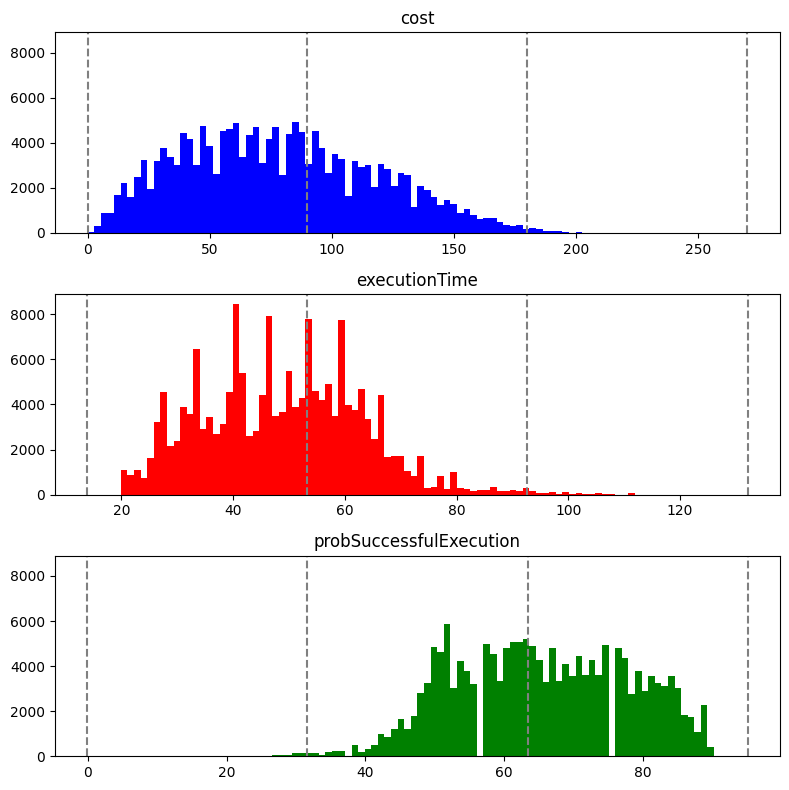

time: 3 s (started: 2023-11-27 22:59:03 -03:00)


In [18]:
#plot_outcome_distribution(outcomes, n_bins=5, filename='500scenarios_outcome_distribution.png')
#plot_outcome_distribution(outcomes, labels=3, filename='500scenarios_outcome_distribution.png', mins_maxs=MIN_MAX_RANGES)
#plot_outcome_distribution(outcomes, labels=3)
#plot_outcome_distribution(outcomes, labels=BINS, filename='500scenarios_outcome_distribution64.png', mins_maxs=MIN_MAX_RANGES)
plot_outcome_distribution(outcomes_df, labels=BINS, filename='500scenarios_outcome_distribution.png', mins_maxs=MIN_MAX_RANGES)

In [19]:
def filter_architecture(experiments, outcomes, dServices):
    d1Services = dServices[0]
    d2Services = dServices[1]
    d3Services = dServices[2]
    exp_filter = experiments[(experiments['d1Services']==d1Services)&(experiments['d2Services']==d2Services)&(experiments['d3Services']==d3Services)]
    policy = exp_filter['policy'].unique()
    #print('policies:', policy)
    if len(policy) > 0:
        exp_filter = exp_filter[exp_filter['policy'] == policy[0]]
    exp_outcomes = dict()
    for k in outcomes.keys():
        exp_outcomes[k] = outcomes[k][exp_filter.index]
    
    return exp_filter, exp_outcomes

time: 1.5 ms (started: 2023-11-27 22:59:11 -03:00)


In [20]:
import itertools
import random

#OPTIONS = [[1, 2, 3], [4, 5, 6], [0, 1, 2]]
#OPTIONS = [[0, 1, 2, 3], [3, 4, 5, 6], [0, 1, 2, 3]]
OPTIONS = [list(range(7)), list(range(7)), list(range(7))] # All possible alternatives
all_combinations = [list(x) for x in itertools.product(*OPTIONS)]
#config = random.choice(all_combinations)
#print(config, "configuation, out of", len(all_combinations), "combinations (policies)")

for c in all_combinations:
    #exp_filtered, exp_outcomes = filter_architecture(experiments, outcomes, c)
    exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, c)
    if exp_filtered.shape[0] == 0:
        print("Warning: configuration", c, "was not sampled!")

time: 687 ms (started: 2023-11-27 22:59:24 -03:00)


In [132]:
#config = [1,5,2]
#config = [1,5,1]
config = [2,5,1]
df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, config)
df_exp_filtered

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
66500,111,33,43,19,3,29,2,5,1,2993,2784,archexploration
66501,128,25,11,21,3,33,2,5,1,2994,2784,archexploration
66502,118,20,32,19,4,43,2,5,1,2995,2784,archexploration
66503,124,14,40,45,5,50,2,5,1,2996,2784,archexploration
66504,136,29,36,45,3,31,2,5,1,2997,2784,archexploration
...,...,...,...,...,...,...,...,...,...,...,...,...
66995,145,32,29,47,2,32,2,5,1,3488,2784,archexploration
66996,127,15,19,27,1,22,2,5,1,3489,2784,archexploration
66997,137,39,27,24,4,47,2,5,1,3490,2784,archexploration
66998,130,19,14,16,4,17,2,5,1,3491,2784,archexploration


time: 20.9 ms (started: 2023-11-27 23:44:25 -03:00)


## **Robustness metric**

In [24]:
from collections import Counter
from natsort import natsorted
import itertools

PERFORMANCE_LABELS = ['fast', 'average', 'slow'] #['very-fast', 'fast', 'average', 'low', 'very-low'] #['fast', 'average', 'low']
RELIABILITY_LABELS = ['unreliable', 'average', 'highly-reliable'] #['unreliable', 'often-unreliable', 'average', 'reliable', 'highly-reliable']
COST_LABELS = ['cheap', 'average', 'expensive'] #['very-cheap', 'cheap', 'average', 'expensive', 'very-expensive']

ALL_TRADEOFF_LABELS = natsorted([','.join(t) for t in itertools.product(*[COST_LABELS, PERFORMANCE_LABELS, RELIABILITY_LABELS])])

ALL_LABELS = dict()
ALL_LABELS['cost'] = COST_LABELS
ALL_LABELS['executionTime'] = PERFORMANCE_LABELS
ALL_LABELS['probSuccessfulExecution'] = RELIABILITY_LABELS

def discretize_outcomes(df_outcomes, all_labels, n_bins=5, mins_maxs=(None,None)):
    df_outcomes_discrete = df_outcomes.copy()
    for idx, c in enumerate(df_outcomes.columns):
        qa = df_outcomes[c]
        min_max = (None,None)
        if mins_maxs != (None,None):
            min_max = mins_maxs[idx]
        qa_bins = get_bins(qa, n_bins, min_max=min_max)
        qa_labels = pd.cut(qa, bins=qa_bins, labels=all_labels[c])
        df_outcomes_discrete[c] = qa_labels
    
    temp = df_outcomes_discrete.to_string(header=False,index=False,index_names=False).split('\n')
    tradeoffs = [','.join(ele.split()) for ele in temp]

    available_tradeoffs = Counter(tradeoffs) #{k:v for (k,v) in natsorted(Counter(tradeoffs).items())}
    return df_outcomes_discrete, available_tradeoffs

time: 38.3 ms (started: 2023-11-27 22:59:59 -03:00)


In [133]:
df_discrete_outcomes, available_tradeoffs = discretize_outcomes(outcomes_df, ALL_LABELS, n_bins=BINS, mins_maxs=MIN_MAX_RANGES)
available_tradeoffs # Whole space

Counter({'cheap,fast,highly-reliable': 37533,
         'cheap,average,average': 26938,
         'average,fast,highly-reliable': 24290,
         'cheap,fast,average': 23795,
         'average,fast,average': 18789,
         'cheap,average,highly-reliable': 16472,
         'average,average,highly-reliable': 12607,
         'average,average,average': 8312,
         'cheap,low,average': 738,
         'cheap,average,unreliable': 360,
         'expensive,fast,average': 310,
         'cheap,low,highly-reliable': 288,
         'expensive,average,highly-reliable': 207,
         'expensive,fast,highly-reliable': 187,
         'cheap,fast,unreliable': 144,
         'expensive,average,average': 30})

time: 1.72 s (started: 2023-11-27 23:44:36 -03:00)


In [106]:
df_exp_outcomes = pd.DataFrame(exp_outcomes) # Only for [2, 5,1]
df_discrete_outcomes, available_tradeoffs = discretize_outcomes(df_exp_outcomes, ALL_LABELS, n_bins=3, mins_maxs=MIN_MAX_RANGES)

69

time: 3.29 ms (started: 2023-11-27 23:22:50 -03:00)


In [134]:
df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, config)

df_exp_outcomes = pd.DataFrame(exp_outcomes)
df_discrete_outcomes, available_tradeoffs = discretize_outcomes(df_exp_outcomes, ALL_LABELS, n_bins=3, mins_maxs=MIN_MAX_RANGES)
available_tradeoffs

Counter({'cheap,fast,highly-reliable': 136,
         'average,fast,highly-reliable': 87,
         'average,fast,average': 68,
         'cheap,fast,average': 62,
         'average,average,highly-reliable': 46,
         'cheap,average,average': 43,
         'cheap,average,highly-reliable': 30,
         'average,average,average': 28})

time: 25.8 ms (started: 2023-11-27 23:45:23 -03:00)


In [135]:
available_tradeoffs.most_common(1)

[('cheap,fast,highly-reliable', 136)]

time: 3.34 ms (started: 2023-11-27 23:45:27 -03:00)


In [123]:
def compute_r1_robustness(df, available_tradeoffs, qat=None):
    if qat is None:
        qat = available_tradeoffs.most_common(1)[0]
        reference_tradeoff = qat[0]
    else:
        reference_tradeoff = qat
        qat = (qat,available_tradeoffs[qat])
    r = qat[1]/(available_tradeoffs.total())
    #print("Robustness of single solution w.r.t tradeoff:", reference_tradeoff, "-->", round(r*100, 2), "%")
    
    return r

time: 1.13 ms (started: 2023-11-27 23:38:57 -03:00)


In [136]:
print(df_exp_filtered.head(1)[['d1Services', 'd2Services', 'd3Services']])

reference_tradeoff = 'cheap,fast,highly-reliable'
r = compute_r1_robustness(df_exp_filtered, available_tradeoffs, qat=reference_tradeoff)
print("Robustness of single solution w.r.t tradeoff:", reference_tradeoff, "-->", round(r*100, 2), "%")

reference_tradeoff = available_tradeoffs.most_common(1)[0][0]
r = compute_r1_robustness(df_exp_filtered, available_tradeoffs)
print("Robustness of single solution w.r.t tradeoff:", reference_tradeoff, "-->", round(r*100, 2), "%")

       d1Services  d2Services  d3Services
66500           2           5           1
Robustness of single solution w.r.t tradeoff: cheap,fast,highly-reliable --> 27.2 %
Robustness of single solution w.r.t tradeoff: cheap,fast,highly-reliable --> 27.2 %
time: 5.12 ms (started: 2023-11-27 23:45:32 -03:00)


In [ ]:
all_combinations.remove([0,0,0]) # This is an invalid configuration

In [130]:
max_r_config = None
min_r_config = None
print(len(all_combinations), "configurations")
r_values = []
reference_tradeoff = 'cheap,fast,highly-reliable'
for c in all_combinations:
    #exp_filtered, exp_outcomes = filter_architecture(experiments, outcomes, c)
    df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, c)
    #print("="*10)
    #print("Configuration:", c, exp_filtered.shape)
    df_exp_outcomes = pd.DataFrame(exp_outcomes)
    df_discrete_outcomes, available_tradeoffs = discretize_outcomes(df_exp_outcomes, ALL_LABELS, n_bins=BINS, mins_maxs=MIN_MAX_RANGES)
    r = compute_r1_robustness(df_exp_filtered, available_tradeoffs, qat=reference_tradeoff)
    #print("Robustness of single solution",c,"w.r.t tradeoff:", reference_tradeoff, "-->", round(r*100, 2), "%")
    r_values.append(r)
    if max_r_config is None:
        max_r_config = (r, c)
    elif r > max_r_config[0]:
        max_r_config = (r, c)
    if min_r_config is None:
        min_r_config = (r, c)
    elif r < min_r_config[0]:
        min_r_config = (r, c)

#print("="*10)
print("Best (max R1) configuration:", max_r_config, reference_tradeoff)
print("Worst (min R1) configuration:", min_r_config, reference_tradeoff)

342 configurations
Best (max R) configuration: (0.312, [1, 1, 1]) cheap,fast,highly-reliable
Worst (min R) configuration: (0.002, [0, 0, 1]) cheap,fast,highly-reliable
time: 3.36 s (started: 2023-11-27 23:42:26 -03:00)


Text(0.5, 1.0, 'Distribution of R1 values in the whole dataset')

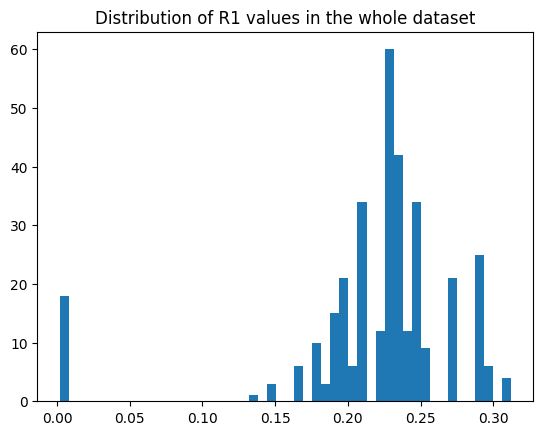

time: 284 ms (started: 2023-11-27 23:42:36 -03:00)


In [131]:
counts, bins, _ = plt.hist(r_values, bins=50)
plt.title("Distribution of R1 values in the whole dataset")

In [63]:
config = [2,5,1] #[1,4,1] #[1,3,1] #[2,5,1]
df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, config)
df_exp_outcomes = pd.DataFrame(exp_outcomes)
df_discrete_outcomes, available_tradeoffs = discretize_outcomes(df_exp_outcomes, ALL_LABELS, n_bins=BINS, mins_maxs=MIN_MAX_RANGES)

counter_frequency_labels = dict()
for t in ALL_TRADEOFF_LABELS:
    counter_frequency_labels[t] = 0
    if t in available_tradeoffs:
        counter_frequency_labels[t] = available_tradeoffs[t]

# Normalization
total = sum(counter_frequency_labels.values(), 0.0)
for k in counter_frequency_labels:
    counter_frequency_labels[k] /= total
    
print(len(available_tradeoffs), available_tradeoffs)
print(len(counter_frequency_labels), counter_frequency_labels)
df_discrete_outcomes

8 Counter({'cheap,fast,highly-reliable': 136, 'average,fast,highly-reliable': 87, 'average,fast,average': 68, 'cheap,fast,average': 62, 'average,average,highly-reliable': 46, 'cheap,average,average': 43, 'cheap,average,highly-reliable': 30, 'average,average,average': 28})
27 {'average,average,average': 0.056, 'average,average,highly-reliable': 0.092, 'average,average,unreliable': 0.0, 'average,fast,average': 0.136, 'average,fast,highly-reliable': 0.174, 'average,fast,unreliable': 0.0, 'average,low,average': 0.0, 'average,low,highly-reliable': 0.0, 'average,low,unreliable': 0.0, 'cheap,average,average': 0.086, 'cheap,average,highly-reliable': 0.06, 'cheap,average,unreliable': 0.0, 'cheap,fast,average': 0.124, 'cheap,fast,highly-reliable': 0.272, 'cheap,fast,unreliable': 0.0, 'cheap,low,average': 0.0, 'cheap,low,highly-reliable': 0.0, 'cheap,low,unreliable': 0.0, 'expensive,average,average': 0.0, 'expensive,average,highly-reliable': 0.0, 'expensive,average,unreliable': 0.0, 'expensive,fa

,cost,executionTime,probSuccessfulExecution
66500,average,average,highly-reliable
66501,average,fast,highly-reliable
66502,average,fast,highly-reliable
66503,cheap,fast,average
66504,average,fast,average
...,...,...,...
66995,average,fast,average
66996,cheap,fast,highly-reliable
66997,average,fast,highly-reliable
66998,cheap,fast,highly-reliable


time: 37 ms (started: 2023-11-27 23:06:55 -03:00)


Categories: 27


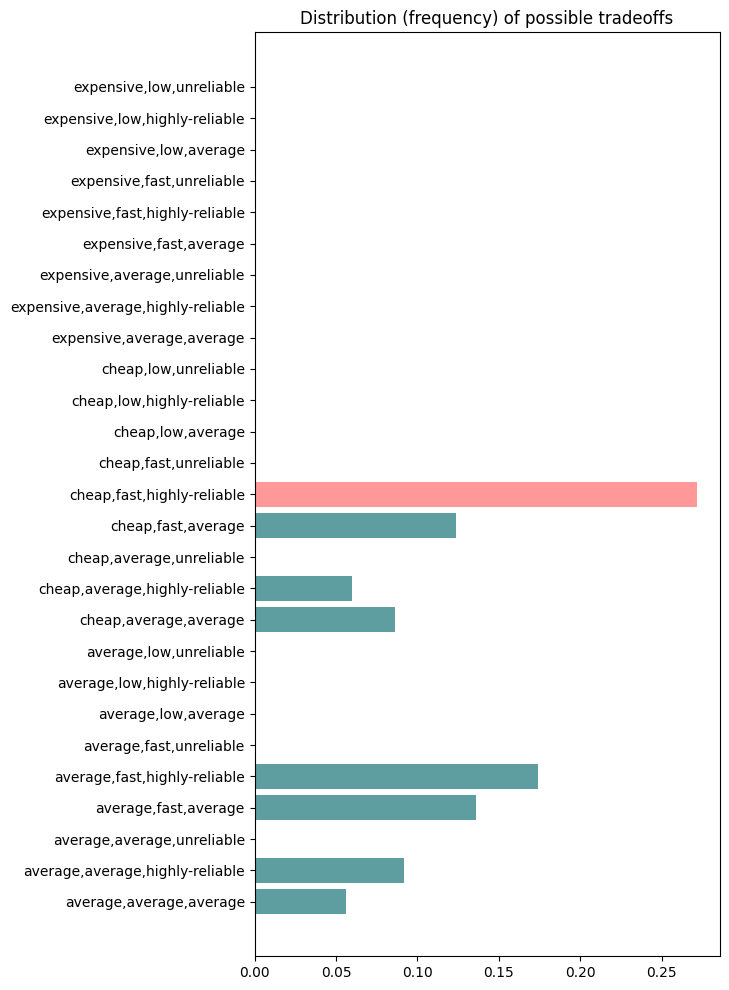

time: 629 ms (started: 2023-11-27 23:07:01 -03:00)


In [64]:
#natsorted_tradeoffs = {k:v for (k,v) in natsorted(available_tradeoffs.items())}
natsorted_tradeoffs = counter_frequency_labels
print('Categories:', len(natsorted_tradeoffs))
fig = plt.figure(figsize=(6,12))
vals = np.array(list(natsorted_tradeoffs.values()))
plt.barh(list(natsorted_tradeoffs.keys()), natsorted_tradeoffs.values(), 
         color=np.where(vals==vals.max(), '#ff9999','cadetblue'))
#plt.xticks(rotation=90)
plt.title("Distribution (frequency) of possible tradeoffs")
plt.savefig("histogram_sobol.png", bbox_inches="tight")
plt.show()

In [33]:
from scipy.stats import entropy

# This is a measure of the homogeneity of space, in terms of the density of solutions. 
# If closer to 1, the space is "bumpy" (valleys and peaks). If closer to 0, the space is flat.
probs = list(counter_frequency_labels.values())
n_base = len(counter_frequency_labels)
print("Entropy:", entropy(probs, base=n_base), "- base", n_base)

Entropy: 0.5914451505221442 - base 27
time: 3.6 ms (started: 2023-11-27 23:01:12 -03:00)


In [35]:
def describe_labels(df_outcomes, all_labels, n_bins=5, show_used=False, mins_maxs=(None,None)):
    list_items = []
    for idx, c in enumerate(df_outcomes.columns):
        qa = df_outcomes[c]
        min_max = (None,None)
        if mins_maxs != (None,None):
            min_max = mins_maxs[idx]
        qa_bins = get_bins(qa, n_bins, min_max=min_max)
        #print(c,qa_bins)
        for i in range (0, n_bins):
            dict_i = dict()
            dict_i['objective'] = c
            dict_i['min'] = qa_bins[i]
            dict_i['max'] = qa_bins[i+1]
            #dict_i['unit'] = 'ms'
            dict_i['label'] = all_labels[c][i]
            list_items.append(dict_i)
    
    df_labels = pd.DataFrame(list_items)
    
    if show_used:
        #_, tradeoffs = discretize_outcomes(df_outcomes, all_labels, n_bins=n_bins)
        tradeoffs = ALL_TRADEOFF_LABELS #tradeoffs.keys()
        all_indices = []
        for idx, c in enumerate(df_outcomes.columns):
            used_labels = {t.split(',')[idx] for t in tradeoffs}
            #print(c, used_labels)
            indices = df_labels[(df_labels['objective'] == c) & (df_labels['label'].isin(used_labels))].index.tolist()
            #print(c, indices)
            all_indices.extend(indices)
        print("Used rows:", all_indices)
        #df_labels_styled = apply_colors(df_labels, all_indices, colors=my_colors, qa_values=False)
        
    return df_labels

def get_label_values(label, df):
    label_list = label.split(',')
    result = []
    for idx, l in enumerate(label.split(',')):
        row = df[df['label'] == l][['min','max']].values.tolist()
        #print(row)
        if len(row) > 1:
            row = [row[idx]]
        result.extend(row)
    result = [tuple(l) for l in result] # Convert to tuple
    return result
    

#describe_labels(df_outcomes, ALL_LABELS, n_bins=3, show_used=True)
df_label_values = describe_labels(outcomes_df, ALL_LABELS, n_bins=BINS, show_used=True, mins_maxs=MIN_MAX_RANGES)
df_label_values

Used rows: [0, 1, 2, 3, 4, 5, 6, 7, 8]


,objective,min,max,label
0,cost,-0.100000,89.966667,cheap
1,cost,89.966667,180.033333,average
2,cost,180.033333,270.100000,expensive
3,executionTime,13.900000,53.300000,fast
4,executionTime,53.300000,92.700000,average
5,executionTime,92.700000,132.100000,low
6,probSuccessfulExecution,-0.100000,31.633333,unreliable
7,probSuccessfulExecution,31.633333,63.366667,average
8,probSuccessfulExecution,63.366667,95.100000,highly-reliable


time: 108 ms (started: 2023-11-27 23:01:27 -03:00)


In [36]:
box = get_label_values('average,fast,highly-reliable', df_label_values)
box

[(89.96666666666668, 180.03333333333336),
 (13.9, 53.3),
 (63.36666666666666, 95.1)]

time: 8.13 ms (started: 2023-11-27 23:01:31 -03:00)


In [38]:
p = 4855 #4516 #4855 #str(4516)
p_exp = experiments_df[experiments_df['policy'] == p]
p_outcomes = outcomes_df.loc[p_exp.index]
p_exp

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model


time: 8.79 ms (started: 2023-11-27 23:01:50 -03:00)


In [39]:
p_outcomes

,cost,executionTime,probSuccessfulExecution


time: 5.2 ms (started: 2023-11-27 23:01:52 -03:00)


In [40]:
get_distribution_bins(p_outcomes['cost'], 5, min_max=cost_min_max)

Using predefined limits (0.999, 210)


[0.998, 168.2, 210]

time: 8.97 ms (started: 2023-11-27 23:01:56 -03:00)


In [41]:
get_bins(p_outcomes['cost'], 5, min_max=cost_min_max)

[0.899,
 42.7392,
 84.57939999999999,
 126.41959999999999,
 168.25979999999998,
 210.1]

time: 3.76 ms (started: 2023-11-27 23:01:58 -03:00)


[(0.999, 210), (19.999, 111), (24.999, 90)]
cost [0.899, 42.7392, 84.57939999999999, 126.41959999999999, 168.25979999999998, 210.1]
executionTime [19.898999999999997, 38.139199999999995, 56.37939999999999, 74.61959999999999, 92.85979999999999, 111.1]
probSuccessfulExecution [24.898999999999997, 37.9392, 50.9794, 64.0196, 77.0598, 90.1]


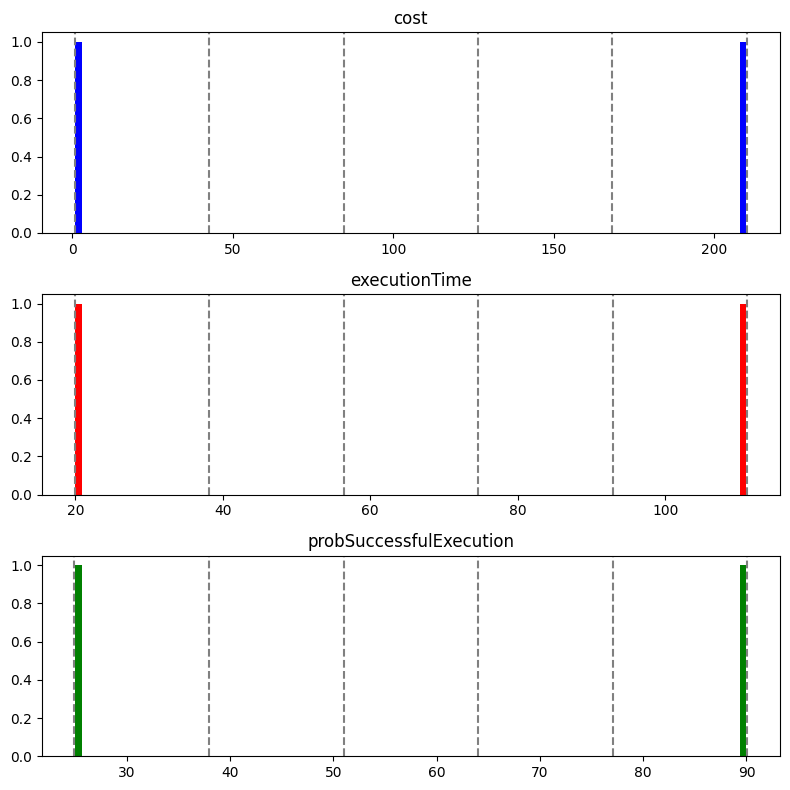

time: 778 ms (started: 2023-11-27 23:02:00 -03:00)


In [42]:
mins_maxs = [cost_min_max, executiontime_min_max, probsuccessfulexecution_min_max] 
print(mins_maxs)
#plot_outcome_distribution(p_outcomes, n_bins=5, mins_maxs=mins_maxs)
plot_outcome_distribution(p_outcomes, mins_maxs=mins_maxs)
#plot_outcome_distribution(p_outcomes)

## **PRIM (Scenario discovery)**

In [44]:
df_label_values

,objective,min,max,label
0,cost,-0.100000,89.966667,cheap
1,cost,89.966667,180.033333,average
2,cost,180.033333,270.100000,expensive
3,executionTime,13.900000,53.300000,fast
4,executionTime,53.300000,92.700000,average
5,executionTime,92.700000,132.100000,low
6,probSuccessfulExecution,-0.100000,31.633333,unreliable
7,probSuccessfulExecution,31.633333,63.366667,average
8,probSuccessfulExecution,63.366667,95.100000,highly-reliable


time: 10.7 ms (started: 2023-11-27 23:02:18 -03:00)


In [45]:
#cheap = (62.14, 113.38)
#fast = (33.94, 56.98)
#average_prob = (53.57939, 67.4196)
box_property = get_label_values('cheap,fast,highly-reliable', df_label_values)
cheap = box_property[0]
fast = box_property[1]
highly_reliable = box_property[2]
print(cheap, fast, highly_reliable)

(-0.1, 89.96666666666668) (13.9, 53.3) (63.36666666666666, 95.1)
time: 6.1 ms (started: 2023-11-27 23:02:20 -03:00)


In [ ]:
from ema_workbench.analysis import prim

c = outcomes['cost']
et = outcomes['executionTime']
pse = outcomes['probSuccessfulExecution']

# Within range/box (property holds)
y = (c >= cheap[0]) & (c <= cheap[1]) & (et >= fast[0]) & (et <= fast[1]) & (pse >= highly_reliable[0]) & (pse <= highly_reliable[1])

# Out of range/box for the 3 objectives (property does not hold)
#y = ((c < average[0])|(c > average[1])) & ((et < fast[0])|(et > fast[1])) & ((pse < highly_reliable[0])|(pse > highly_reliable[1]))

x = experiments

In [ ]:
prim_alg = prim.Prim(x, y, threshold=0.8)
# Threshold is the minimum score of the density of the last box

In [ ]:
box1 = prim_alg.find_box()

In [ ]:
box1.show_tradeoff()
plt.savefig("prim-tradeoff.png", bbox_inches="tight")
plt.show()

In [ ]:
box1.show_pairs_scatter()
plt.savefig('prim-boxes.png', bbox_inches="tight")
plt.show()

In [ ]:
box1.inspect()
box1.inspect(style='graph')
plt.show()

In [ ]:
import prim # This is another implementation of PRIM (used by Rhodium)

#df = pd.DataFrame(np.random.rand(1000, 3), columns=["x1", "x2", "x3"])
#response = df["x1"]*df["x2"] + 0.2*df["x3"]
#p = prim.Prim(df, response, threshold=0.5, threshold_type=">")
p = prim.Prim(x, y)
    
#all_boxes = p.find_all()
#print(len(all_boxes), 'boxes')

In [ ]:
box2 = p.find_box() #all_boxes[0] #p.find_box()
box2.show_tradeoff()
plt.show()

In [ ]:
fig = plt.figure(figsize=(24,12))
box2.show_details(fig)
plt.savefig('prim-boxes1.png', bbox_inches="tight")
plt.show()

In [ ]:
#box2.show_ppt()
#plt.show()

In [ ]:
#box2.show_scatter()
#plt.show()

In [ ]:
box2.limits

## **Info-Gap**

In [214]:
def eval_property(outcomes_df):
    c = outcomes_df['cost']
    et = outcomes_df['executionTime']
    pse = outcomes_df['probSuccessfulExecution']
    # Property
    y = (c >= cheap[0]) & (c <= cheap[1]) & (et >= fast[0]) & (et <= fast[1]) & (pse >= highly_reliable[0]) & (pse <= highly_reliable[1])
    
    return y

time: 803 µs (started: 2023-11-28 00:14:44 -03:00)


In [215]:
PARAMETERS = ['deviceCPUCyles', 'deviceCost', 'lbExecTime', 'lbFailureProb', 'serviceCost', 'serviceFailureProb']
REFERENCE_VECTOR = [130, 20, 30, 30, 3, 30] 
MIN_RANGE = [100, 0, 10, 10, 1, 10]
MAX_RANGE = [150, 40, 50, 50, 5, 50]

#experiments[PARAMETERS]
#a = np.array([109, 35, 21, 29, 2, 44])
a = np.array(REFERENCE_VECTOR)
(experiments_df[PARAMETERS] == a).all(1).any() # Check if the reference vector exists in the dataset of experiments

False

time: 8.17 ms (started: 2023-11-28 00:14:50 -03:00)


In [216]:
def create_parameter_vectors(df, prop, verbose=True):
    df_experiments = df[PARAMETERS].copy()
    a = np.array(REFERENCE_VECTOR)
    selected_indices = list(np.where((df_experiments == a).all(1))[0])
    idx = None
    if selected_indices: # List is not empty
        if verbose:
            print("Reference vector exists already! ", selected_indices)
        idx = selected_indices[0]
        df_experiments['property'] = prop # This is the property under test
    else:
        idx = 0
        df_experiments['property'] = prop
        if verbose:
            print("Adding reference vector at 0")
        df_experiments.loc[-1] = REFERENCE_VECTOR + [True] # adding a row
        df_experiments.index = df_experiments.index + 1  # shifting index
        df_experiments = df_experiments.sort_index()  # sorting by index    
    if verbose:
        print(idx)
    return df_experiments

time: 2.63 ms (started: 2023-11-28 00:15:05 -03:00)


In [274]:
config = [2,5,1] #[1,4,1] #[1,3,1] #[2,5,1]
df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, config)
df_exp_outcomes = pd.DataFrame(exp_outcomes)
df_exp_filtered

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
66500,111,33,43,19,3,29,2,5,1,2993,2784,archexploration
66501,128,25,11,21,3,33,2,5,1,2994,2784,archexploration
66502,118,20,32,19,4,43,2,5,1,2995,2784,archexploration
66503,124,14,40,45,5,50,2,5,1,2996,2784,archexploration
66504,136,29,36,45,3,31,2,5,1,2997,2784,archexploration
...,...,...,...,...,...,...,...,...,...,...,...,...
66995,145,32,29,47,2,32,2,5,1,3488,2784,archexploration
66996,127,15,19,27,1,22,2,5,1,3489,2784,archexploration
66997,137,39,27,24,4,47,2,5,1,3490,2784,archexploration
66998,130,19,14,16,4,17,2,5,1,3491,2784,archexploration


time: 21.9 ms (started: 2023-11-28 00:33:02 -03:00)


In [275]:
y = eval_property(df_exp_outcomes)
df_exp_filtered = create_parameter_space(df_exp_filtered, y, verbose=False)
print("Property TRUE:", df_exp_filtered[df_exp_filtered['property']].shape[0])
print("Property FALSE:", df_exp_filtered[~df_exp_filtered['property']].shape[0])
df_exp_filtered

Property TRUE: 137
Property FALSE: 364


,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,property
0,130,20,30,30,3,30,True
66501,111,33,43,19,3,29,False
66502,128,25,11,21,3,33,False
66503,118,20,32,19,4,43,False
66504,124,14,40,45,5,50,False
...,...,...,...,...,...,...,...
66996,145,32,29,47,2,32,False
66997,127,15,19,27,1,22,True
66998,137,39,27,24,4,47,False
66999,130,19,14,16,4,17,True


time: 22.9 ms (started: 2023-11-28 00:33:20 -03:00)


In [186]:
from scipy.spatial.distance import pdist, squareform
from sklearn import preprocessing
from scipy.spatial import distance

def get_matrix(df, normalize=None, p='property'):
    X = df.drop(p, axis=1)
    #norm_x = preprocessing.normalize(x, norm='l2')
    dist = squareform(pdist(X.values, 'euclidean'))
    #max_distance = df_distance.max().max()
    #print("Max distance: ", max_distance)
    #df_distance/max_distance
    df_distances = pd.DataFrame(dist)
    if normalize is not None:
        df_distances = df_distances/normalize
    return df_distances

time: 1.71 ms (started: 2023-11-28 00:04:52 -03:00)


In [263]:
# Normalize matrix based on max and min ranges
max_distance1 = distance.euclidean(REFERENCE_VECTOR, MAX_RANGE) #df_distances[0].max()
max_distance2 = distance.euclidean(REFERENCE_VECTOR, MIN_RANGE) #df_distances[0].max()
max_distance = max([max_distance1, max_distance2])
print("Max distance for reference point 0:", max_distance1, max_distance2, max_distance)
get_matrix(df_exp_filtered, normalize=max_distance)

Max distance for reference point 0: 44.76605857119878 50.039984012787215 50.039984012787215


,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,0.000000,0.572604,0.437828,0.418712,0.565587,0.389047,0.512620,0.607790,0.638864,0.673553,...,0.471640,0.395663,0.467814,0.583999,0.561690,0.514952,0.304388,0.545458,0.498800,0.421089
1,0.572604,0.000000,0.746932,0.462663,0.814211,0.739679,0.416800,1.142065,0.248799,0.799111,...,0.276907,0.667897,0.436458,0.659473,1.043196,0.925974,0.713012,0.725505,0.787279,0.883601
2,0.437828,0.746932,0.000000,0.517659,0.858848,0.716365,0.650018,0.724679,0.783720,0.593495,...,0.619505,0.460067,0.809291,0.926621,0.495990,0.731535,0.360821,0.543257,0.363577,0.805829
3,0.418712,0.462663,0.517659,0.000000,0.586728,0.704277,0.632897,0.942009,0.383880,0.391095,...,0.226093,0.562755,0.531365,0.644155,0.719702,0.845728,0.561334,0.560978,0.678869,0.768541
4,0.565587,0.814211,0.858848,0.586728,0.000000,0.547285,0.892595,0.967524,0.810031,0.748534,...,0.638864,0.920784,0.487463,0.346710,0.808551,0.698869,0.793091,0.751463,1.032228,0.608447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.514952,0.925974,0.731535,0.845728,0.698869,0.240639,0.837423,0.732354,1.022120,1.083937,...,0.845728,0.783720,0.653083,0.643845,0.623681,0.000000,0.696293,0.591135,0.849967,0.500000
497,0.304388,0.713012,0.360821,0.561334,0.793091,0.624001,0.513399,0.519200,0.793846,0.676511,...,0.646630,0.377058,0.719980,0.855820,0.619182,0.696293,0.000000,0.743180,0.286128,0.586728
498,0.545458,0.725505,0.543257,0.560978,0.751463,0.592822,0.839091,0.976971,0.715807,0.812001,...,0.565233,0.677986,0.666101,0.715249,0.548378,0.591135,0.743180,0.000000,0.794852,0.819832
499,0.498800,0.787279,0.363577,0.678869,1.032228,0.813720,0.593831,0.609431,0.859777,0.784993,...,0.757286,0.302413,0.907679,1.067790,0.686183,0.849967,0.286128,0.794852,0.000000,0.783975


time: 32.2 ms (started: 2023-11-28 00:27:52 -03:00)


In [269]:
def compute_r2_robustness(df, prop, verbose=True):
    max_distance1 = distance.euclidean(REFERENCE_VECTOR, MAX_RANGE) #df_distances[0].max()
    max_distance2 = distance.euclidean(REFERENCE_VECTOR, MIN_RANGE) #df_distances[0].max()
    max_distance = max([max_distance1, max_distance2])
    if verbose:
        print("Max distance for reference point 0:", max_distance1, max_distance2, max_distance)
    
    df_prop = create_parameter_vectors(df, prop, verbose=verbose)
    df_distances = get_matrix(df_prop, normalize=None)
    df_prop['alpha'] = (df_distances[0]/max_distance).tolist()
    r2 = df_prop[df_prop['property']]['alpha'].max()
    
    return r2

time: 1.14 ms (started: 2023-11-28 00:28:36 -03:00)


In [265]:
n = df_exp_filtered[df_exp_filtered['property']].shape[0]
r1 = n / df_exp_filtered.shape[0]
qat = available_tradeoffs.most_common(1)
print("Robustness (R1) of single solution w.r.t tradeoff:", qat[0][0], "-->", round(r1*100, 2), "%")

Robustness (R1) of single solution w.r.t tradeoff: average,fast,highly-reliable --> 27.35 %
time: 2.28 ms (started: 2023-11-28 00:27:59 -03:00)


In [266]:
config = [2,5,1] #[1,4,1] #[1,3,1] #[2,5,1]
df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, config)
df_exp_outcomes = pd.DataFrame(exp_outcomes)

y = eval_property(df_exp_outcomes)
r2 = compute_r2_robustness(df_exp_filtered, y)
qat = available_tradeoffs.most_common(1)
print("Robustness (R2) of single solution w.r.t tradeoff:", qat[0][0], "-->", round(r2*100, 2), "%")

Max distance for reference point 0: 44.76605857119878 50.039984012787215 50.039984012787215
Adding reference vector at 0
0
Robustness (R2) of single solution w.r.t tradeoff: average,fast,highly-reliable --> 86.76 %
time: 18.9 ms (started: 2023-11-28 00:28:02 -03:00)


In [270]:
max_r_config = None
min_r_config = None
print(len(all_combinations), "configurations")
r_values = []
reference_tradeoff = 'cheap,fast,highly-reliable'
for c in all_combinations:
    #exp_filtered, exp_outcomes = filter_architecture(experiments, outcomes, c)
    df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, c)
    #print("="*10)
    #print("Configuration:", c, exp_filtered.shape)
    df_exp_outcomes = pd.DataFrame(exp_outcomes)
    y = eval_property(df_exp_outcomes)
    #df_discrete_outcomes, available_tradeoffs = discretize_outcomes(df_exp_outcomes, ALL_LABELS, n_bins=BINS, mins_maxs=MIN_MAX_RANGES)
    r = compute_r2_robustness(df_exp_filtered, y, verbose=False)
    #print("Robustness of single solution",c,"w.r.t tradeoff:", reference_tradeoff, "-->", round(r*100, 2), "%")
    r_values.append(r)
    if max_r_config is None:
        max_r_config = (r, c)
    elif r > max_r_config[0]:
        max_r_config = (r, c)
    if min_r_config is None:
        min_r_config = (r, c)
    elif r < min_r_config[0]:
        min_r_config = (r, c)

#print("="*10)
print("Best (max R2) configuration:", max_r_config, reference_tradeoff)
print("Worst (min R2) configuration:", min_r_config, reference_tradeoff)

342 configurations
Best (max R2) configuration: (0.8676379009451751, [0, 1, 1]) cheap,fast,highly-reliable
Worst (min R2) configuration: (0.8367077579444765, [0, 0, 1]) cheap,fast,highly-reliable
time: 2.37 s (started: 2023-11-28 00:28:40 -03:00)


Text(0.5, 1.0, 'Distribution of R2 values in the whole dataset')

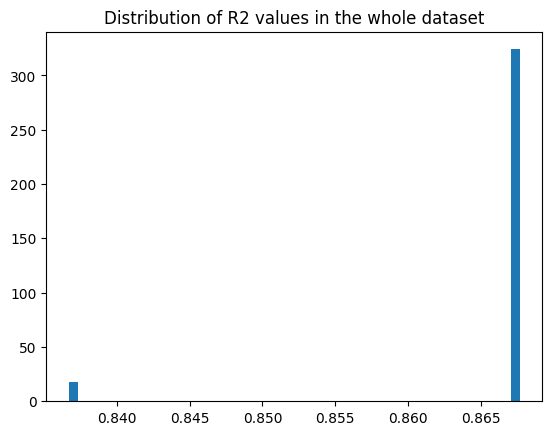

time: 223 ms (started: 2023-11-28 00:28:46 -03:00)


In [271]:
counts, bins, _ = plt.hist(r_values, bins=50)
plt.title("Distribution of R2 values in the whole dataset")

In [ ]:
#!wget 'https://www.nayuki.io/res/smallest-enclosing-circle/smallestenclosingcircle.py'

In [292]:
from sklearn.utils.validation import check_symmetric
from smallestenclosingcircle import make_circle
from sklearn import manifold
import math

# The spread indicator for the architecture domain
def mas(distance, max_d):
    return math.sqrt(distance.max(axis=1).pow(2).sum() / (distance.shape[0]*max_d**2))

def min_enclosing_circle(df): # Utility function for drawing circles
    points = df[['x','y']].values
    points = [(x,y) for x,y in points]
    circle = make_circle(points) # This calls a external fuction/module
    center = (circle[0],circle[1])
    diameter = circle[2]

    return center, diameter

def get_farthest_point(df):
    list_r = []
    for index, row in df.iterrows():
        r = math.sqrt(row['x']**2 + row['y']**2)
        list_r.append(r)
    return max(list_r)

# Main function for displaying the view for the architectural space
def show_multiple_mds_view(df, title, criterion='property', colors=['red'], grid=False, size=(10,10), fix_symmetry=False,
                           max_d=None, x_lims=None, y_lims=None, max_circle=None, cat_legends=None):
    
    #df.loc[len(df)] = MIN_RANGE + [True]
    #df.loc[len(df)] = MAX_RANGE + [True]
    dist_df = get_matrix(df, normalize=max_d)
    # Computation of the embeddings
    mds = manifold.MDS(
      n_components=2,
      max_iter=3000,
      eps=1e-9,
      random_state=1,
      dissimilarity="precomputed",
      n_jobs=1,
      normalized_stress="auto",
    )
    #print(dist_df.shape, len(dist_df.values))
    data = dist_df.values
    if fix_symmetry:
        data_repaired = check_symmetric(data)
        pos = mds.fit(data_repaired).embedding_
        #pos = mds.fit(data.astype(np.float64)).embedding_
        # https://stackoverflow.com/questions/16990996/multidimensional-scaling-fitting-in-numpy-pandas-and-sklearn-valueerror
    else:
        pos = mds.fit(data).embedding_

    if max_d is None:
        max_d = dist_df.max().max()
    print("Max distance=", max_d)
    spread = mas(dist_df, max_d=max_d)

    # View
    fig = plt.figure(1, figsize=size)

    embeddings_df = pd.DataFrame(pos, columns=['x','y'])
    refx, refy = embeddings_df.at[0,'x'], embeddings_df.at[0,'y']
    embeddings_df['x'] = embeddings_df['x'] - refx
    embeddings_df['y'] = embeddings_df['y'] - refy
    embeddings_df[criterion] = df[criterion]

    center, diameter = min_enclosing_circle(embeddings_df)
    print('global center and diameter:', center, diameter)

    #cc1 = plt.Circle((0.0,0.0), max_d, color='gray', fill=False)
    #plt.gca().add_artist(cc1)
    if max_circle is not None:
        cc2 = plt.Circle(center, max_circle, color='black', fill=False, linestyle='--')
        plt.gca().add_artist(cc2)

    unique_categories = set(df[criterion].values)
    print(unique_categories)
    for idx,c in enumerate(unique_categories):
        cat_df = df[df[criterion] == c]
        cat_embeddings_df = embeddings_df[embeddings_df[criterion] == c]
        print(cat_df.shape)
        cat_dist_df = get_matrix(cat_df, normalize=max_d)
        cat_spread = mas(cat_dist_df, max_d=max_d)
        print('--mas:', cat_spread)

        cat_df = embeddings_df[embeddings_df[criterion] == c]
        if cat_legends is not None:
          label = f'{cat_legends[c]} [MAS= {cat_spread:.2f}]'
        else:
          label = f'{c} [MAS= {cat_spread:.2f}]'
        plt.scatter(cat_df['x'], cat_df['y'], color=colors[idx], s=80, label=label, alpha=0.7, edgecolors='black')
        
        print(cat_df.shape,c, label)
        center_cc, diameter_cc = min_enclosing_circle(cat_df)
        print('--center and diameter:', center_cc, diameter_cc)
        center_cc = (0.0, 0.0)
        diameter_cc = get_farthest_point(cat_embeddings_df)
        print('--center and diameter:', center_cc, diameter_cc)
        cat_cc = plt.Circle(center_cc, diameter_cc, color=colors[idx], fill=False, label='', linestyle='--')
        plt.gca().add_artist(cat_cc)

    # This is the reference vector
    plt.scatter(embeddings_df.at[0,'x'], embeddings_df.at[0,'y'], color='black', s=100, label='Reference', edgecolors='black')
    if x_lims is not None:
        plt.xlim([x_lims[0], x_lims[1]])
    if y_lims is not None:
        plt.ylim([y_lims[0], y_lims[1]])
    if not grid:
        plt.grid(False)
        plt.axis('off')

    plt.legend(title='', loc='upper left', ncols=3) #len(unique_categories))

    plt.savefig('metric.png')
    #plt.savefig(metric+'.pdf')
    plt.show()

    return embeddings_df

time: 6.89 ms (started: 2023-11-28 09:30:35 -03:00)


In [289]:
config = [2,5,1] #[1,4,1] #[1,3,1] #[2,5,1]
df_exp_filtered, exp_outcomes = filter_architecture(experiments_df, outcomes_df, config)
df_exp_outcomes = pd.DataFrame(exp_outcomes)

max_distance1 = distance.euclidean(REFERENCE_VECTOR, MAX_RANGE) #df_distances[0].max()
max_distance2 = distance.euclidean(REFERENCE_VECTOR, MIN_RANGE) #df_distances[0].max()
max_distance = max([max_distance1, max_distance2])
    
y = eval_property(df_exp_outcomes)
#r = compute_r2_robustness(df_exp_filtered, y, verbose=False)
df_exp_prop = create_parameter_vectors(df_exp_filtered, y, verbose=False)
df_distances = get_matrix(df_exp_prop, normalize=None)
df_exp_prop['alpha'] = (df_distances[0]/max_distance).tolist()

time: 20.8 ms (started: 2023-11-28 09:28:56 -03:00)


In [290]:
df_exp_prop

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,property,alpha
0,130,20,30,30,3,30,True,0.000000
66501,111,33,43,19,3,29,False,0.572604
66502,128,25,11,21,3,33,False,0.437828
66503,118,20,32,19,4,43,False,0.418712
66504,124,14,40,45,5,50,False,0.565587
...,...,...,...,...,...,...,...,...
66996,145,32,29,47,2,32,False,0.514952
66997,127,15,19,27,1,22,True,0.304388
66998,137,39,27,24,4,47,False,0.545458
66999,130,19,14,16,4,17,True,0.498800


time: 12.6 ms (started: 2023-11-28 09:29:03 -03:00)


Max distance= 50.039984012787215
global center and diameter: (0.01804424143211289, -0.06888070894381307) 0.8861959606528338
{False, True}
(364, 7)
--mas: 0.02544723460497421
(0, 3) False Property FALSE [MAS= 0.03]


/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_37851/1526175731.py:88: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  label = f'{cat_legends[c]} [MAS= {cat_spread:.2f}]'


TypeError: 'NoneType' object is not subscriptable

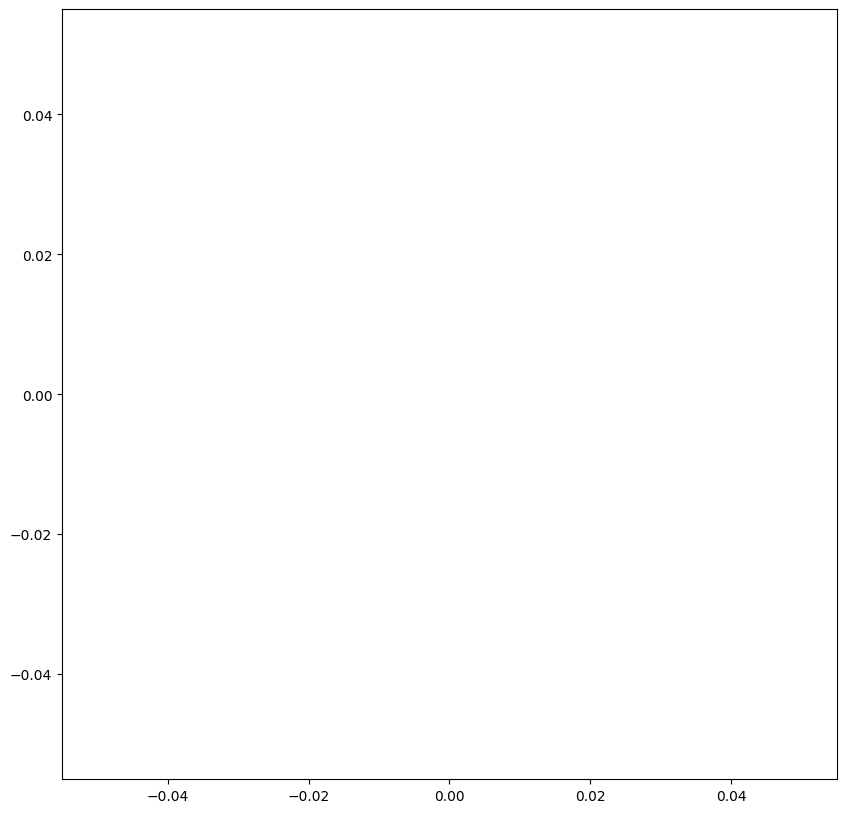

time: 10.1 s (started: 2023-11-28 09:30:40 -03:00)


In [293]:
X = df_exp_prop.drop('alpha', axis=1)
pos_2d = show_multiple_mds_view(X, "No title", colors=['blue', 'red'], grid=False, 
                                x_lims=(-1.5,1.5), y_lims=(-1.5,1.5), max_d=max_distance,
                                fix_symmetry=False, max_circle=None, cat_legends=['Property FALSE', 'Property TRUE'])

In [ ]:
pos_2d